In [ ]:
from src.pca import PCA

import inspect
import time
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nbformat
%matplotlib inline


In [43]:
data_path = 'data/ps8_data.mat'
data = scipy.io.loadmat(data_path)

Xplan = data['Xplan']
Xsim  = data['Xsim']

print(f"Xplan shape: {Xplan.shape}")
print(f"Xsim shape: {Xsim.shape}")

Xplan shape: (728, 97)
Xsim shape: (8, 2)


# Q1

In [96]:
pca = PCA(n_components=8)

start_time = time.time()
pca.fit(Xplan)
Xplan_pca_transformed = pca.transform(Xplan)
end_time   = time.time()

exp_var = pca.explained_variance_.astype(np.float32)*(len(Xplan) - 1)
acc_var = np.cumsum(exp_var)
print(f"pca fit time: {end_time - start_time:.4f} seconds")

pca fit time: 0.0025 seconds


## (a)

Looking at the plot below, we see a steep dropoff after the 3rd principal component. The top 3 principal components captures 44.8% of the total variance


In [97]:
# percentage explained variance
total_var = np.trace(pca.noise_cov_)*(len(Xplan) - 1)
explained_var_percentage = (acc_var[2]/total_var)*100
print(f"The top 3 principal components explain {explained_var_percentage:.3f}% of all variance")

The top 3 principal components explain 44.791% of all variance


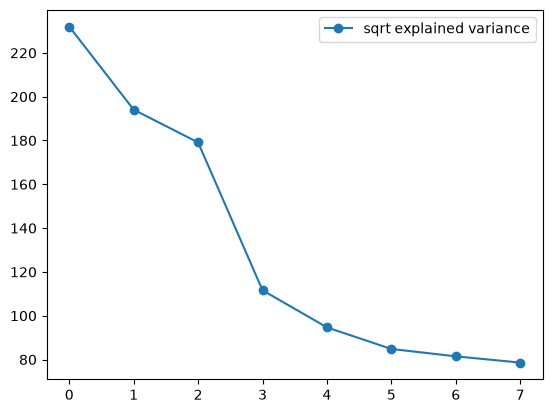

In [98]:
fig, ax = plt.subplots()

sqrt_exp_var = np.sqrt(exp_var)
line1, = ax.plot(sqrt_exp_var, marker='o', label='sqrt explained variance')
ax.legend()
plt.show()
plt.close('all')

## (b)

In [99]:
Z_8d = pca.transform(X = Xplan)
Z_3d = Z_8d[:, :3]
Z_3d.shape

(728, 3)

In [100]:
import plotly.express as px

In [101]:
# 8 reach angles with 91 trials each
num_reaches_per_angle = 91
angles_deg = [0, 45, 90, 135, 180, 225, 270, 315]

# Generate categorical labels corresponding to the 8 blocks
reach_labels = [
    f"Angle {i+1} ({angles_deg[i]}°)" 
    for i in range(8) 
    for _ in range(num_reaches_per_angle)
]

# 3. Create DataFrame
df = pd.DataFrame({
    'PC1': Z_3d[:, 0],
    'PC2': Z_3d[:, 1],
    'PC3': Z_3d[:, 2],
    'Reach Direction': reach_labels
})

# 4. Plotly 3D Scatter Plot
fig = px.scatter_3d(
    df, 
    x='PC1', 
    y='PC2', 
    z='PC3',
    color='Reach Direction',
    title='Reach data projected into three-dimensional PC space'
)

# 5. Fine-tune marker style for visibility
fig.update_traces(marker=dict(size=4, opacity=0.85, line=dict(width=0.5, color='black')))

# Format axes and font size to match MATLAB
fig.update_layout(
    scene=dict(
        xaxis_title='PC 1',
        yaxis_title='PC 2',
        zaxis_title='PC 3'
    ),
    title_font_size=16
)

fig.show(renderer='browser') 

![Q1b Plot](q1b.png)

## (c)

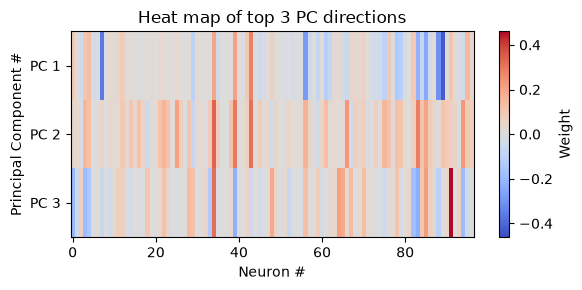

In [102]:
U_M = pca.components_[:3, :]

plt.figure(figsize=(6, 3))
plt.xlabel('Neuron #')
plt.ylabel('Principal Component #')
plt.title('Heat map of top 3 PC directions')

max_val = np.max(np.abs(U_M))
plt.imshow(U_M, aspect='auto', cmap='coolwarm', vmin=-max_val, vmax=max_val)

plt.yticks([0, 1, 2], ['PC 1', 'PC 2', 'PC 3'])  
plt.colorbar(label='Weight')
plt.tight_layout()
plt.show()

# Q2

## (a)

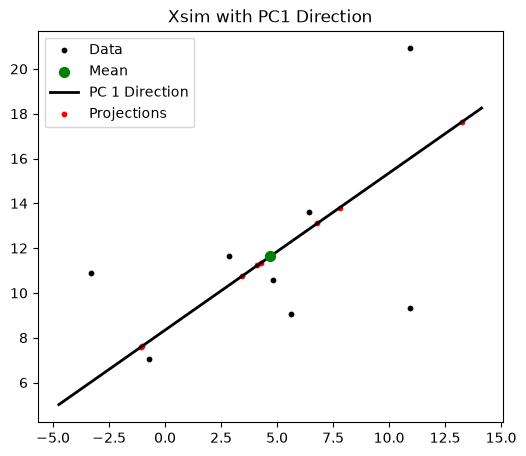

In [ ]:
pca = PCA(n_components=1)
pca.fit(Xsim)
x, y = pca.components_[0, 0], pca.components_[0, 1]


Xsim_mean = Xsim.mean(axis=0)

# Scale factor to make the vector visible against data spread
scale = np.sqrt(pca.explained_variance_[0]) * 2  

plt.figure(figsize=(6, 6))

# 1. Scatter plot of data points and mean
plt.scatter(Xsim[:, 0], Xsim[:, 1], color='black', s=10, label='Data')
plt.scatter(Xsim_mean[0], Xsim_mean[1], color='green', s=50, zorder=5, label='Mean')

# 2. Plot the PC direction as a line
plt.plot(
    [Xsim_mean[0] - scale * x, Xsim_mean[0] + scale * x], 
    [Xsim_mean[1] - scale * y, Xsim_mean[1] + scale * y], 
    color='black', linewidth=2, label='PC 1 Direction'
)

# 3. Plot the projection points onto the PC direction
Z = pca.transform(Xsim)
X_projected = Xsim_mean + Z @ pca.components_[:1, :]
x_coords = X_projected[:, 0]
y_coords = X_projected[:, 1]
plt.scatter(x_coords, y_coords, color='red', s=10, label='Projections')

# 4. draw lines from original points to their projections
for i in range(Xsim.shape[0]):
    plt.plot(
        [Xsim[i, 0], x_coords[i]], 
        [Xsim[i, 1], y_coords[i]], 
        color='red', linewidth=0.5, alpha=0.5
    )

plt.title('Xsim with PC1 Direction')
plt.gca().set_aspect('equal') 
plt.legend()
plt.show()